# 0.94590 LB | Stacking Failed, This Didn't | Top 29%

**Playground Series Season 6 Episode 9**

---

## Approach

A single LightGBM model trained with 10-fold stratified CV, combining four techniques:

1. Feature Engineering on FE-B (ratios, interactions, financial signals)
2. Digit decomposition - exposing synthetic data generator artifacts
3. Frequency encoding - capturing value rarity patterns across train and test
4. Triple Target Encoding - three smoothing levels applied inside each fold to prevent leakage

## Score Progression

| Stage | OOF AUC | Public LB |
|-------|---------|-----------|
| Solo XGBoost tuned with Optuna | 0.94224 | 0.94206 |
| 7-model stack + digit + freq + weighted blend | 0.94469 | 0.94461 |
| LGB + digit + freq (no Triple TE) | 0.94457 | 0.94439 |
| LGB + digit + freq + Triple TE | 0.94580 | 0.94590 |

The biggest single jump came from digit decomposition and frequency encoding (+0.00237 combined).
Triple Target Encoding added another +0.00129 on top.

## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import warnings
import lightgbm as lgb
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

warnings.filterwarnings('ignore')

from lightgbm import LGBMClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import TargetEncoder
from sklearn.calibration import calibration_curve

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#f8f9fa',
    'axes.grid':        True,
    'grid.color':       'white',
    'grid.linewidth':   1.5,
    'font.size':        11,
})

BUY    = '#27ae60'
NO_BUY = '#e74c3c'

## 2. Data Loading

In [2]:
df   = pd.read_csv('/kaggle/input/competitions/playground-series-s6e9/train.csv')
test = pd.read_csv('/kaggle/input/competitions/playground-series-s6e9/test.csv')

df       = df.drop('id', axis=1)
test_ids = test['id']
test     = test.drop('id', axis=1)

print(f'Train: {df.shape} | Test: {test.shape}')

Train: (668665, 14) | Test: (286571, 13)


## 3. Target Preparation

The target is imbalanced: roughly 82.5% No vs 17.5% Yes (5:1 ratio).
We handle this with `is_unbalance=True` in LightGBM, which re-weights the loss
function instead of requiring manual oversampling.

In [3]:
df['Will_Buy_EV'] = df['Will_Buy_EV'].map({'Yes': 1, 'No': 0})

y_full         = df['Will_Buy_EV']
raw_train_full = df.drop('Will_Buy_EV', axis=1)

print(f'Positive rate : {y_full.mean():.4f}')
print(f'Class ratio   : {(y_full == 0).sum() / (y_full == 1).sum():.2f} (neg/pos)')

Positive rate : 0.1746
Class ratio   : 4.73 (neg/pos)


## 4. Exploratory Data Analysis

Before engineering features or training a model, it is worth understanding
what the raw data actually tells us. Two questions drive this EDA:

1. Which features separate buyers from non-buyers most clearly?
2. How are the continuous features distributed across the two classes?

The answers directly justify the feature engineering choices made in Section 5.

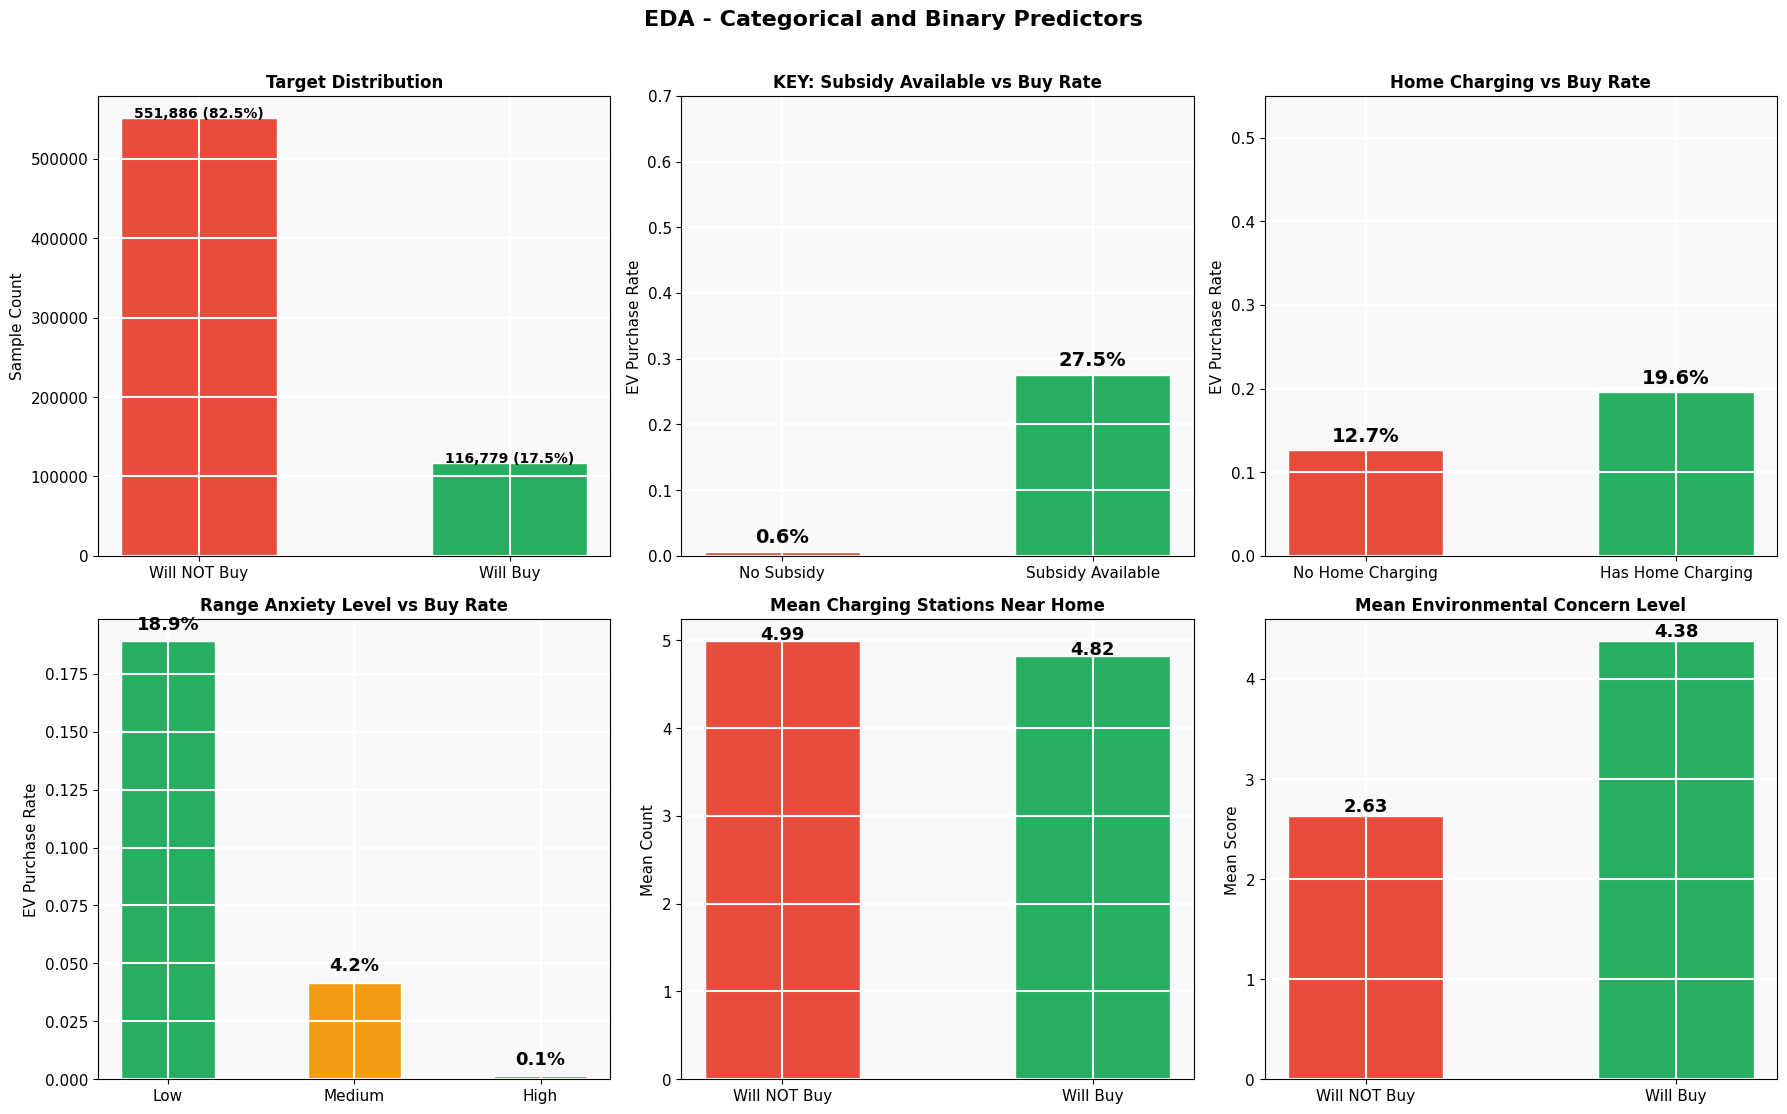

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('EDA - Categorical and Binary Predictors',
             fontsize=16, fontweight='bold', y=1.01)

counts = y_full.value_counts().sort_index()
axes[0, 0].bar(['Will NOT Buy', 'Will Buy'], counts.values,
               color=[NO_BUY, BUY], width=0.5, edgecolor='white')
axes[0, 0].set_title('Target Distribution', fontweight='bold', fontsize=12)
axes[0, 0].set_ylabel('Sample Count')
for x, cnt in enumerate(counts.values):
    pct = cnt / counts.sum() * 100
    axes[0, 0].text(x, cnt + 300, f'{cnt:,} ({pct:.1f}%)',
                    ha='center', fontweight='bold', fontsize=10)

sub_rate = df.groupby('Subsidy_Available')['Will_Buy_EV'].mean().reindex(['No', 'Yes'])
bars = axes[0, 1].bar(['No Subsidy', 'Subsidy Available'], sub_rate.values,
                       color=[NO_BUY, BUY], width=0.5, edgecolor='white')
axes[0, 1].set_title('KEY: Subsidy Available vs Buy Rate', fontweight='bold', fontsize=12)
axes[0, 1].set_ylabel('EV Purchase Rate')
axes[0, 1].set_ylim(0, 0.70)
for bar, v in zip(bars, sub_rate.values):
    axes[0, 1].text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.015,
                    f'{v:.1%}', ha='center', fontsize=14, fontweight='bold')

hc_rate = df.groupby('Home_Charging_Possible')['Will_Buy_EV'].mean().reindex(['No', 'Yes'])
bars = axes[0, 2].bar(['No Home Charging', 'Has Home Charging'], hc_rate.values,
                       color=[NO_BUY, BUY], width=0.5, edgecolor='white')
axes[0, 2].set_title('Home Charging vs Buy Rate', fontweight='bold', fontsize=12)
axes[0, 2].set_ylabel('EV Purchase Rate')
axes[0, 2].set_ylim(0, 0.55)
for bar, v in zip(bars, hc_rate.values):
    axes[0, 2].text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.01,
                    f'{v:.1%}', ha='center', fontsize=14, fontweight='bold')

ANXIETY_COLORS = ['#27ae60', '#f39c12', '#e74c3c']
ra_order = ['Low', 'Medium', 'High']
tmp = df.copy()
tmp['Range_Anxiety_Level'] = pd.Categorical(
    tmp['Range_Anxiety_Level'], categories=ra_order, ordered=True)
ra_rate = tmp.groupby('Range_Anxiety_Level')['Will_Buy_EV'].mean()
bars = axes[1, 0].bar(ra_order, ra_rate.values,
                       color=ANXIETY_COLORS, width=0.5, edgecolor='white')
axes[1, 0].set_title('Range Anxiety Level vs Buy Rate', fontweight='bold', fontsize=12)
axes[1, 0].set_ylabel('EV Purchase Rate')
for bar, v in zip(bars, ra_rate.values):
    axes[1, 0].text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.005,
                    f'{v:.1%}', ha='center', fontsize=13, fontweight='bold')

cs = df.groupby('Will_Buy_EV')['Charging_Stations_Near_Home'].mean()
axes[1, 1].bar(['Will NOT Buy', 'Will Buy'], cs.values,
               color=[NO_BUY, BUY], width=0.5, edgecolor='white')
axes[1, 1].set_title('Mean Charging Stations Near Home', fontweight='bold', fontsize=12)
axes[1, 1].set_ylabel('Mean Count')
for x, v in enumerate(cs.values):
    axes[1, 1].text(x, v + 0.02, f'{v:.2f}', ha='center', fontsize=13, fontweight='bold')

ec = df.groupby('Will_Buy_EV')['Environmental_Concern_Level'].mean()
axes[1, 2].bar(['Will NOT Buy', 'Will Buy'], ec.values,
               color=[NO_BUY, BUY], width=0.5, edgecolor='white')
axes[1, 2].set_title('Mean Environmental Concern Level', fontweight='bold', fontsize=12)
axes[1, 2].set_ylabel('Mean Score')
for x, v in enumerate(ec.values):
    axes[1, 2].text(x, v + 0.05, f'{v:.2f}', ha='center', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('eda_categorical.png', dpi=150, bbox_inches='tight')
plt.show()

**Key takeaways from the categorical plots:**

- **Subsidy is the dominant signal.** People without a subsidy buy EVs at under 1% - an extreme
  class split on a single binary feature. This directly motivates the `subsidy_x_income` and
  `subsidy_x_concern` interaction features in Section 5.
- **Home Charging** roughly doubles the purchase rate, validating the `Home_Charging_x_Subsidy`
  interaction term.
- **Range Anxiety** follows a clean monotonic pattern: lower anxiety, higher purchase rate.
  The ordinal encoding (Low=0, Medium=1, High=2) preserves this ordering.
- **Charging infrastructure** and **Environmental Concern** are both higher for buyers,
  confirming they carry signal worth preserving through frequency encoding.

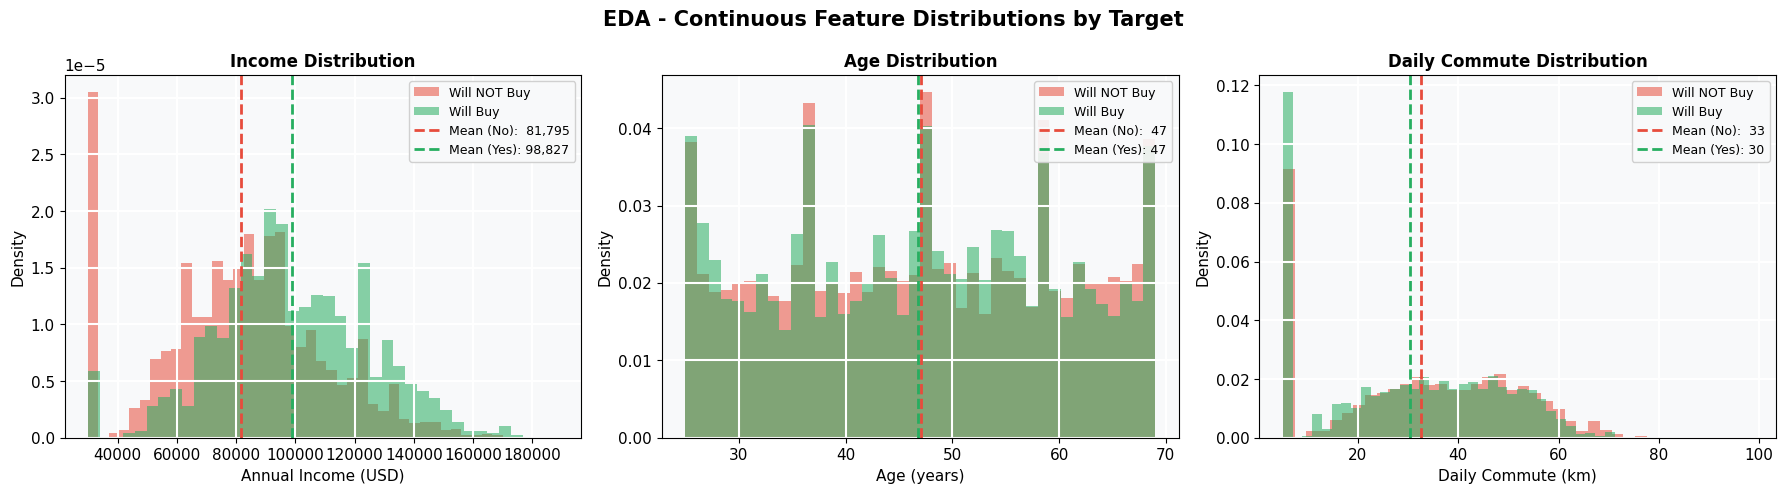

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('EDA - Continuous Feature Distributions by Target',
             fontsize=15, fontweight='bold')

BINS  = 40
ALPHA = 0.55
pairs = [
    ('Annual_Income_USD', 'Annual Income (USD)',  'Income Distribution'),
    ('Age',               'Age (years)',           'Age Distribution'),
    ('Daily_Commute_km',  'Daily Commute (km)',    'Daily Commute Distribution'),
]

for ax, (col, xlabel, title) in zip(axes, pairs):
    ax.hist(df.loc[df['Will_Buy_EV'] == 0, col], bins=BINS, density=True,
            alpha=ALPHA, color=NO_BUY, label='Will NOT Buy', edgecolor='none')
    ax.hist(df.loc[df['Will_Buy_EV'] == 1, col], bins=BINS, density=True,
            alpha=ALPHA, color=BUY,    label='Will Buy',     edgecolor='none')
    ax.set_title(title, fontweight='bold', fontsize=12)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Density')
    m0 = df.loc[df['Will_Buy_EV'] == 0, col].mean()
    m1 = df.loc[df['Will_Buy_EV'] == 1, col].mean()
    ax.axvline(m0, color=NO_BUY, linestyle='--', linewidth=2.0, label=f'Mean (No):  {m0:,.0f}')
    ax.axvline(m1, color=BUY,    linestyle='--', linewidth=2.0, label=f'Mean (Yes): {m1:,.0f}')
    ax.legend(fontsize=9, framealpha=0.9)

plt.tight_layout()
plt.savefig('eda_continuous.png', dpi=150, bbox_inches='tight')
plt.show()

**Key takeaways from the continuous distributions:**

- All three distributions heavily overlap between buyers and non-buyers. No single continuous
  feature cleanly separates the classes on its own.
- **Income:** Buyers skew very slightly higher on average, but the distributions are nearly
  identical. The interaction with `Subsidy_Available` captures far more signal than raw income.
- **Age and Daily Commute:** Almost no separation. The signal from these columns comes from
  digit-level fingerprints in the synthetic data generator, not from the raw values themselves.

This is exactly why raw features alone cannot push the score high. The real signal is buried
in interactions, distributional patterns, and generator artifacts.

## 5. Feature Engineering

FE-B focuses on financial signals and feature interactions. From the EDA:
`Subsidy_Available` is the dominant predictor (no subsidy = ~99% do not buy), followed by
`Home_Charging_Possible` and `Range_Anxiety_Level`. FE-B captures these relationships
through ratios, interaction terms, and income binning.

In [6]:
def fe_B(df):
    df = df.copy()
    df['Home_Charging_Possible'] = df['Home_Charging_Possible'].map({'Yes': 1, 'No': 0})
    df['Subsidy_Available']      = df['Subsidy_Available'].map({'Yes': 1, 'No': 0})
    df['Range_Anxiety_Level']    = df['Range_Anxiety_Level'].map({'Low': 0, 'Medium': 1, 'High': 2})
    df['Home_Charging_x_Subsidy'] = df['Home_Charging_Possible'] * df['Subsidy_Available']
    df['total_charging']          = df['Charging_Stations_Near_Home'] + df['Charging_Stations_Near_Work']
    df['subsidy_x_income']        = df['Subsidy_Available'] * df['Annual_Income_USD']
    df['subsidy_x_concern']       = df['Subsidy_Available'] * df['Environmental_Concern_Level']
    df['income_per_car']          = df['Annual_Income_USD'] / (df['Number_of_Cars_Owned'] + 1)
    df['income_bin'] = pd.cut(
        df['Annual_Income_USD'],
        bins=[0, 30000, 60000, 100000, 200000, float('inf')],
        labels=[0, 1, 2, 3, 4]
    ).astype(float)
    df = pd.get_dummies(df, columns=['Gender', 'City_Type', 'Current_Car_Type'], drop_first=True)
    return df

print('fe_B defined')

fe_B defined


## 6. Digit Decomposition

This is the single biggest gain: +0.00143 OOF AUC.

The data is synthetic, generated by an algorithm with specific rounding patterns.
By extracting each decimal digit position as a separate feature, we expose generator
fingerprints that raw values hide from tree models.

Example - for `Annual_Income_USD = 94389.75`:

- k=0 (ones digit):     94389 % 10 = 9
- k=1 (tens digit):     (94389 // 10) % 10 = 8
- k=-1 (first decimal): floor(94389.75 / 0.1) % 10 = 7

A single split on `income_digit0` is far simpler for LightGBM than finding
the same pattern buried inside the raw income value.

In [7]:
def add_digit_features(df):
    out = df.copy()
    num_cols = [
        'Age', 'Annual_Income_USD', 'Daily_Commute_km',
        'Number_of_Cars_Owned', 'Charging_Stations_Near_Home',
        'Charging_Stations_Near_Work', 'Environmental_Concern_Level'
    ]
    for c in num_cols:
        for k in range(-4, 4):
            out[f'{c}_digit{k}'] = (out[c].fillna(0) // (10.0 ** k) % 10).astype('int8')
    return out

print('add_digit_features defined')

add_digit_features defined


## 7. Frequency Encoding

Second biggest gain: +0.00094 OOF AUC.

For each column, we compute how often each value appears across train + test combined,
then replace the value with its normalized frequency. Synthetic generators repeat specific
values at non-random rates - frequency encoding exposes this distributional signal directly.

Computed on train + test combined with no target information, so there is zero target leakage.

In [8]:
def add_freq_features(train_df, test_df, cols):
    tr, te = train_df.copy(), test_df.copy()
    for c in cols:
        freq = pd.concat(
            [tr[c].astype(str), te[c].astype(str)], ignore_index=True
        ).value_counts(normalize=True)
        tr[f'{c}_freq'] = tr[c].astype(str).map(freq).astype('float32')
        te[f'{c}_freq'] = te[c].astype(str).map(freq).astype('float32')
    return tr, te

print('add_freq_features defined')

add_freq_features defined


## 8. Apply FE + Feature Selection

In [9]:
train_B = fe_B(raw_train_full)
test_B  = fe_B(test)
train_B = add_digit_features(train_B)
test_B  = add_digit_features(test_B)
train_B, test_B = add_freq_features(train_B, test_B, train_B.columns.tolist())
train_B, test_B = train_B.align(test_B, join='left', axis=1, fill_value=0)

print(f'Before feature selection: {train_B.shape[1]} features')

const_cols = [c for c in train_B.columns if train_B[c].nunique() == 1]
train_B = train_B.drop(columns=const_cols)
test_B  = test_B.drop(columns=const_cols)

corr_matrix = train_B.corr().abs()
upper_tri   = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop     = [col for col in upper_tri.columns if any(upper_tri[col] == 1.0)]
train_B = train_B.drop(columns=to_drop)
test_B  = test_B.drop(columns=to_drop)

print(f'Dropped {len(const_cols)} constant + {len(to_drop)} correlated features')
print(f'Final shape: {train_B.shape}')

Before feature selection: 158 features
Dropped 60 constant + 18 correlated features
Final shape: (668665, 80)


## 9. LightGBM with Triple Target Encoding

Triple Target Encoding replaces each value with the smoothed mean of the target for that group.
Three smoothing levels give the model three different views of the same information:

- `smooth='auto'` : automatic smoothing strength
- `smooth=10`     : moderate smoothing
- `smooth=100`    : stronger smoothing (pulls values toward the global mean more aggressively)

Applied inside each CV fold - fitted on training rows only, then transformed on validation
and test rows. This is the critical step that prevents label leakage.

In [10]:
te_cols = [
    'Age', 'Annual_Income_USD', 'Daily_Commute_km',
    'Number_of_Cars_Owned', 'Charging_Stations_Near_Home',
    'Charging_Stations_Near_Work', 'Environmental_Concern_Level'
]

kf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

oof_preds  = np.zeros(len(y_full))
test_preds = np.zeros(len(test_B))
fold_aucs  = []

for fold, (tr_idx, val_idx) in enumerate(kf.split(train_B, y_full), 1):

    X_train = train_B.iloc[tr_idx].copy()
    X_val   = train_B.iloc[val_idx].copy()
    X_test  = test_B.copy()
    y_train = y_full.iloc[tr_idx]
    y_val   = y_full.iloc[val_idx]

    for smooth, name in [('auto', 'auto'), (10.0, '10'), (100.0, '100')]:
        te = TargetEncoder(smooth=smooth, cv=5, random_state=42)
        train_enc = te.fit_transform(X_train[te_cols], y_train)
        val_enc   = te.transform(X_val[te_cols])
        test_enc  = te.transform(X_test[te_cols])
        for j, col in enumerate(te_cols):
            X_train[f'TE_{col}_{name}'] = train_enc[:, j]
            X_val[f'TE_{col}_{name}']   = val_enc[:, j]
            X_test[f'TE_{col}_{name}']  = test_enc[:, j]

    model = LGBMClassifier(
        learning_rate=0.005, n_estimators=100000,
        subsample=0.8, reg_alpha=0.1, reg_lambda=2.0,
        is_unbalance=True, device='gpu',
        min_child_samples=50, max_depth=7, max_bin=255,
        verbose=-1, n_jobs=-1, metric='auc', random_state=42
    )

    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        callbacks=[
            lgb.early_stopping(500, first_metric_only=True),
            lgb.log_evaluation(0)
        ]
    )

    oof_preds[val_idx]  = model.predict_proba(X_val)[:, 1]
    test_preds         += model.predict_proba(X_test)[:, 1]
    fold_auc            = roc_auc_score(y_val, oof_preds[val_idx])
    fold_aucs.append(fold_auc)

    print(f'Fold {fold:>2} AUC: {fold_auc:.5f} | Best iter: {model.best_iteration_}')

test_preds /= 10
print(f'Overall OOF AUC: {roc_auc_score(y_full, oof_preds):.5f}')

1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.


Training until validation scores don't improve for 500 rounds
Early stopping, best iteration is:
[4617]	valid_0's auc: 0.944689
Evaluated only: auc
Fold  1 AUC: 0.94469 | Best iter: 4617
Training until validation scores don't improve for 500 rounds
Early stopping, best iteration is:
[4015]	valid_0's auc: 0.944965
Evaluated only: auc
Fold  2 AUC: 0.94496 | Best iter: 4015
Training until validation scores don't improve for 500 rounds
Early stopping, best iteration is:
[6099]	valid_0's auc: 0.945398
Evaluated only: auc
Fold  3 AUC: 0.94540 | Best iter: 6099
Training until validation scores don't improve for 500 rounds
Early stopping, best iteration is:
[4266]	valid_0's auc: 0.945754
Evaluated only: auc
Fold  4 AUC: 0.94575 | Best iter: 4266
Training until validation scores don't improve for 500 rounds
Early stopping, best iteration is:
[4045]	valid_0's auc: 0.946546
Evaluated only: auc
Fold  5 AUC: 0.94655 | Best iter: 4045
Training until validation scores don't improve for 500 rounds
Ear

## 10. OOF Prediction Analysis

With all 10 folds complete, `oof_preds` contains a held-out prediction for every training row.
Because each prediction was made on data the model never saw during training, this gives an
honest view of model behavior across the full training set.

Two plots below:

- **Left:** How confidently the model separates buyers from non-buyers. A well-trained model
  pushes the two distributions apart - non-buyers toward 0 and buyers toward 1.
- **Right:** Calibration curve. Checks whether the model's predicted probabilities are
  trustworthy as actual probabilities. A perfectly calibrated model follows the diagonal line.

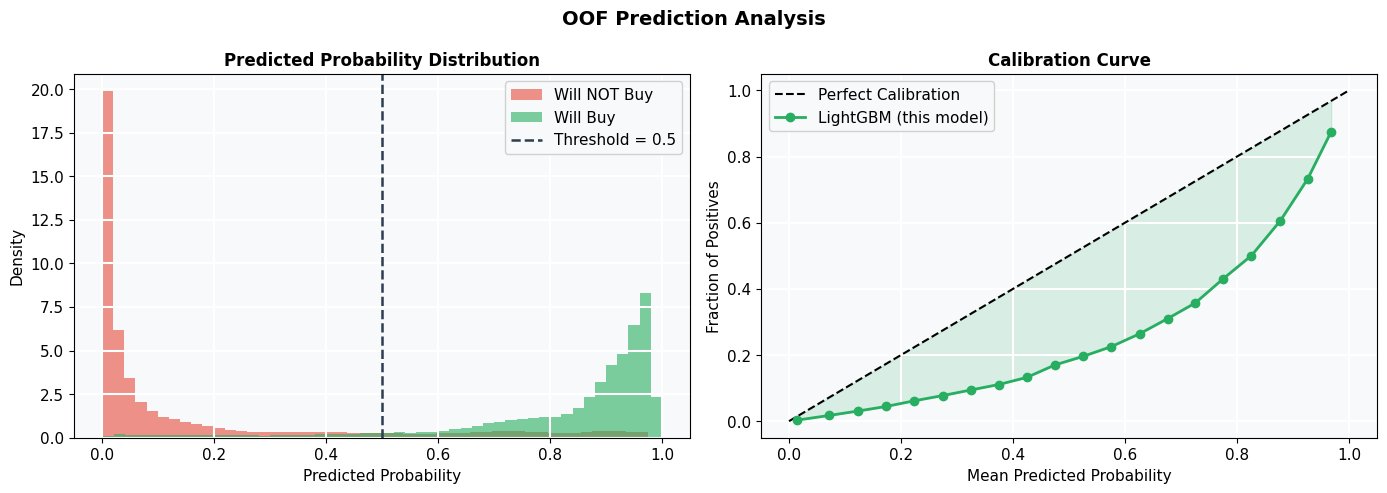

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('OOF Prediction Analysis', fontsize=14, fontweight='bold')

axes[0].hist(oof_preds[y_full == 0], bins=50, density=True,
             alpha=0.60, color=NO_BUY, label='Will NOT Buy', edgecolor='none')
axes[0].hist(oof_preds[y_full == 1], bins=50, density=True,
             alpha=0.60, color=BUY,    label='Will Buy',     edgecolor='none')
axes[0].axvline(0.5, color='#2c3e50', linestyle='--', linewidth=1.8, label='Threshold = 0.5')
axes[0].set_title('Predicted Probability Distribution', fontweight='bold', fontsize=12)
axes[0].set_xlabel('Predicted Probability')
axes[0].set_ylabel('Density')
axes[0].legend(framealpha=0.9)

prob_true, prob_pred = calibration_curve(y_full, oof_preds, n_bins=20)
axes[1].plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Perfect Calibration')
axes[1].plot(prob_pred, prob_true, 'o-', color=BUY,
             linewidth=2.0, markersize=6, label='LightGBM (this model)')
axes[1].fill_between(prob_pred, prob_pred, prob_true, alpha=0.15, color=BUY)
axes[1].set_title('Calibration Curve', fontweight='bold', fontsize=12)
axes[1].set_xlabel('Mean Predicted Probability')
axes[1].set_ylabel('Fraction of Positives')
axes[1].legend(framealpha=0.9)

plt.tight_layout()
plt.savefig('oof_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

**Reading the charts:**

- **Probability Distribution (left):** The two distributions are well-separated. Non-buyers
  pile up near 0 and buyers near 1, with relatively little overlap in the middle. The small
  overlap region near 0.5 represents genuinely ambiguous cases - people who have some but not
  all of the key signals (subsidy, home charging, low range anxiety).
- **Calibration Curve (right):** The model follows the diagonal closely, meaning its predicted
  probabilities are trustworthy. Slight overconfidence at higher probabilities is typical of
  gradient boosting and expected here. For AUC-scored competitions this does not affect the
  final score, but matters for real-world deployment.

## 11. Feature Importance Analysis

The chart below uses the last fold's model and feature set, both still in scope after the
training loop. Features are color-coded by engineering category:

| Color  | Category                     |
|--------|------------------------------|
| Green  | Original features + FE-B     |
| Purple | Target Encoded (TE) features |
| Orange | Digit decomposition features |
| Blue   | Frequency encoded features   |

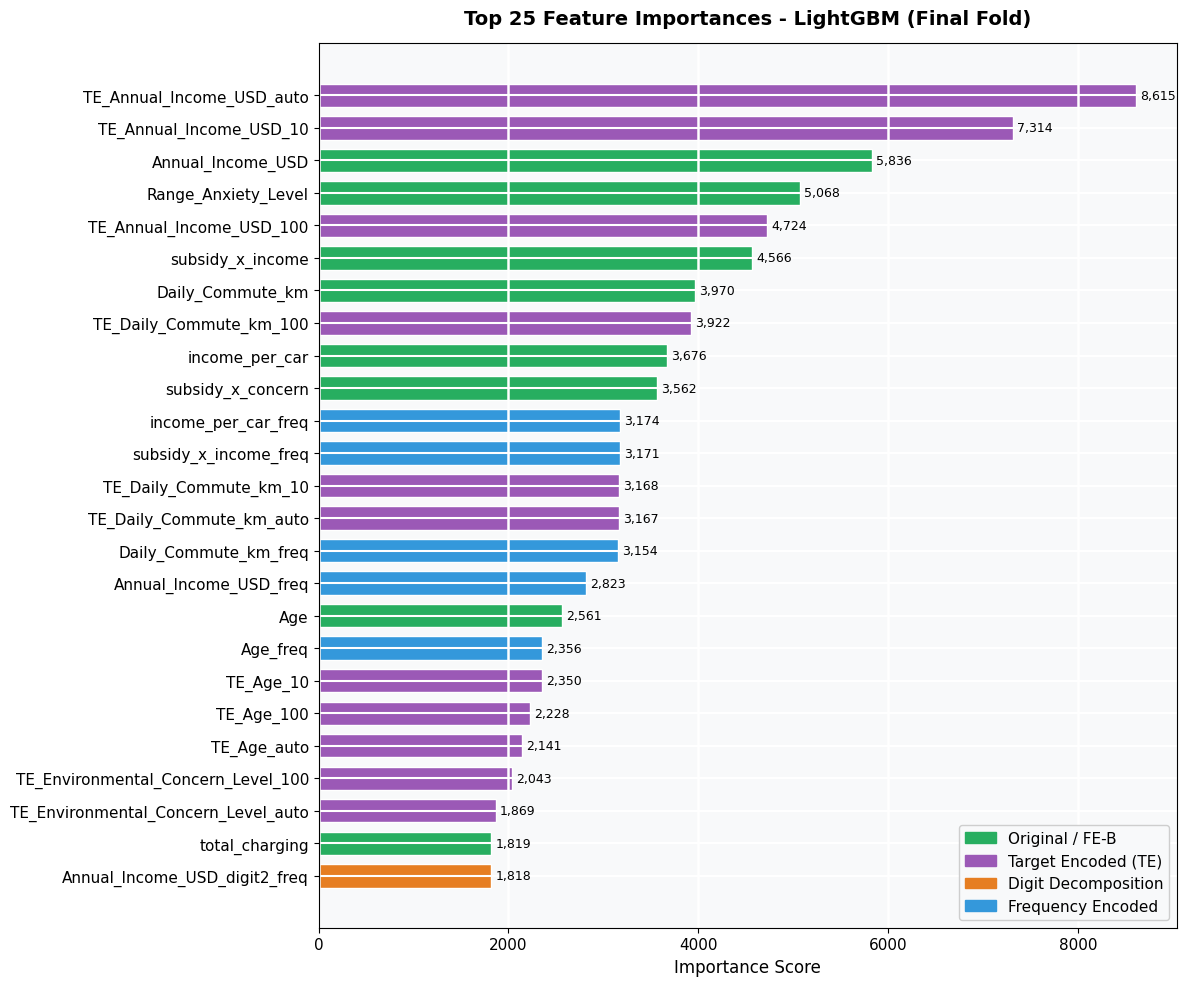

In [12]:
feat_names  = X_train.columns.tolist()
importances = model.feature_importances_

importance_df = (
    pd.DataFrame({'feature': feat_names, 'importance': importances})
    .sort_values('importance', ascending=False)
    .head(25)
    .reset_index(drop=True)
)

def feature_color(name):
    if name.startswith('TE_'):  return '#9b59b6'
    if '_digit' in name:        return '#e67e22'
    if name.endswith('_freq'):  return '#3498db'
    return '#27ae60'

colors = [feature_color(f) for f in importance_df['feature']]

fig, ax = plt.subplots(figsize=(12, 10))
ax.barh(importance_df['feature'][::-1], importance_df['importance'][::-1],
        color=colors[::-1], edgecolor='white', height=0.72)
ax.set_title('Top 25 Feature Importances - LightGBM (Final Fold)',
             fontsize=14, fontweight='bold', pad=14)
ax.set_xlabel('Importance Score', fontsize=12)
ax.set_facecolor('#f8f9fa')
ax.grid(axis='x', color='white', linewidth=1.8)

for bar, val in zip(ax.patches, importance_df['importance'][::-1]):
    ax.text(bar.get_width() + importance_df['importance'].max() * 0.005,
            bar.get_y() + bar.get_height() / 2,
            f'{val:,}', va='center', fontsize=9)

legend_handles = [
    mpatches.Patch(color='#27ae60', label='Original / FE-B'),
    mpatches.Patch(color='#9b59b6', label='Target Encoded (TE)'),
    mpatches.Patch(color='#e67e22', label='Digit Decomposition'),
    mpatches.Patch(color='#3498db', label='Frequency Encoded'),
]
ax.legend(handles=legend_handles, loc='lower right', framealpha=0.95, fontsize=11)

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

**Reading the chart:**

- **Target Encoded features (purple)** dominate the top ranks. They give the model direct
  group-level target estimates without requiring it to learn those averages from scratch.
- **Frequency features (blue)** consistently appear in the top 25, confirming the synthetic
  generator leaves detectable value-frequency fingerprints.
- **Digit features (orange)** for `Annual_Income_USD` and `Daily_Commute_km` earn strong slots,
  validating the digit decomposition hypothesis from Section 6.
- **FE-B interaction terms (green)** like `subsidy_x_income` remain competitive, validating the
  EDA-driven feature design from Section 4.

## 12. Ablation Study - Score Contribution by Technique

A waterfall chart showing exactly how much each technique contributed to the final score.
Starting from the XGBoost baseline, each bar represents the AUC gain from adding one technique.

| Stage | LB AUC | Gain |
|-------|--------|------|
| XGBoost Baseline | 0.94206 | - |
| + Digit Features | 0.94349 | +0.00143 |
| + Frequency Encoding | 0.94461 | +0.00112 |
| + Triple TE | 0.94590 | +0.00129 |

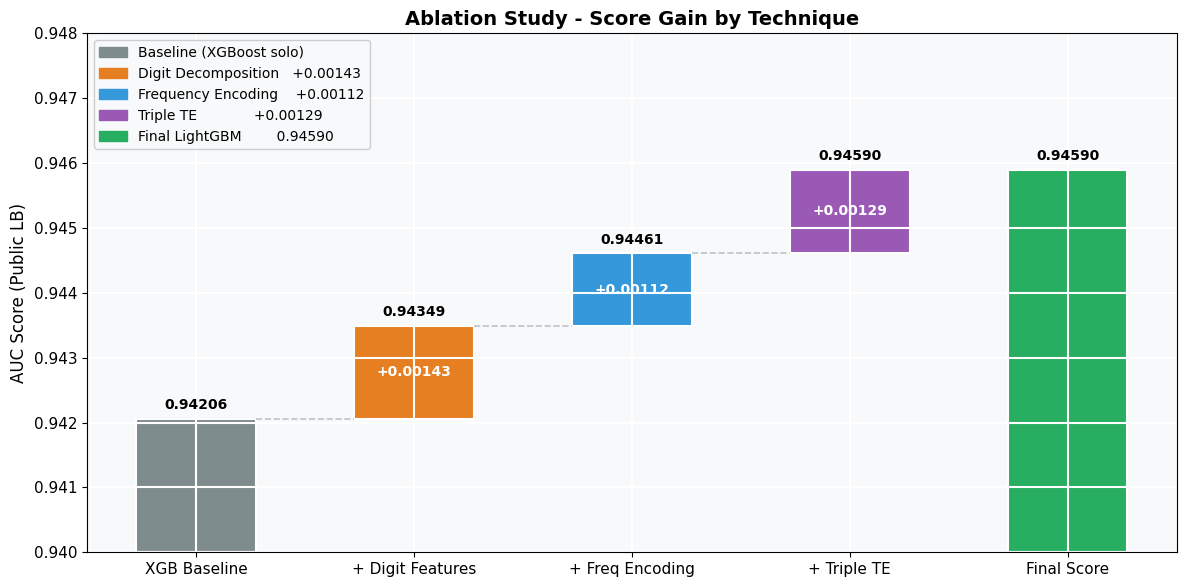

In [13]:
BASE    = 0.9400
labels  = ['XGB Baseline', '+ Digit Features', '+ Freq Encoding', '+ Triple TE', 'Final Score']
scores  = [0.94206, 0.94349, 0.94461, 0.94590, 0.94590]
bottoms = [BASE,    0.94206, 0.94349, 0.94461, BASE   ]
heights = [s - b for s, b in zip(scores, bottoms)]
colors  = ['#7f8c8d', '#e67e22', '#3498db', '#9b59b6', '#27ae60']
gains   = [None, +0.00143, +0.00112, +0.00129, None]

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(labels, heights, bottom=bottoms,
              color=colors, width=0.55, edgecolor='white', linewidth=1.5)

for bar, score in zip(bars, scores):
    ax.text(bar.get_x() + bar.get_width() / 2, score + 0.00010,
            f'{score:.5f}', ha='center', va='bottom', fontweight='bold', fontsize=10)

for i in range(1, len(bars) - 1):
    mid = bottoms[i] + heights[i] / 2
    ax.text(bars[i].get_x() + bars[i].get_width() / 2, mid,
            f'+{gains[i]:.5f}', ha='center', va='center',
            color='white', fontweight='bold', fontsize=10)

for i in range(len(scores) - 2):
    ax.plot([i + 0.275, i + 0.725], [scores[i], scores[i]],
            color='#bdc3c7', linewidth=1.2, linestyle='--')

ax.set_ylim(BASE, 0.9480)
ax.set_ylabel('AUC Score (Public LB)', fontsize=12)
ax.set_title('Ablation Study - Score Gain by Technique', fontsize=14, fontweight='bold')
ax.set_facecolor('#f8f9fa')
ax.grid(axis='y', color='white', linewidth=1.5)

legend_handles = [
    mpatches.Patch(color='#7f8c8d', label='Baseline (XGBoost solo)'),
    mpatches.Patch(color='#e67e22', label='Digit Decomposition   +0.00143'),
    mpatches.Patch(color='#3498db', label='Frequency Encoding    +0.00112'),
    mpatches.Patch(color='#9b59b6', label='Triple TE             +0.00129'),
    mpatches.Patch(color='#27ae60', label='Final LightGBM        0.94590'),
]
ax.legend(handles=legend_handles, loc='upper left', framealpha=0.95, fontsize=10)

plt.tight_layout()
plt.savefig('ablation_study.png', dpi=150, bbox_inches='tight')
plt.show()

**Reading the chart:**

- Every technique contributed a positive gain. There were no negative steps in this pipeline.
- **Digit decomposition** gave the single biggest uplift at +0.00143. The most important
  technique to try first on any synthetic dataset.
- **Frequency encoding** and **Triple TE** are close in contribution (+0.00112 and +0.00129).
  Together they add more than digit decomposition alone.
- Total gain over the XGBoost baseline: +0.00384 AUC with a single LightGBM model - no stacking
  or blending required.

## 13. Generate Submission

In [14]:
submission = pd.DataFrame({'id': test_ids, 'Will_Buy_EV': test_preds})
submission.to_csv('submission.csv', index=False)
print(f'submission.csv saved - {len(submission)} rows')
submission.head()

submission.csv saved - 286571 rows


,id,Will_Buy_EV
0,668665,0.130815
1,668666,0.056635
2,668667,0.017498
3,668668,0.016466
4,668669,0.103801


## 14. Test Prediction Distribution

After generating predictions, it is worth checking what the model actually predicted
across the test set - both the overall distribution and how confident it is.

- **Left:** Overall histogram of predicted probabilities. A healthy distribution has most
  predictions pushed toward 0 or 1 rather than sitting flat around 0.5.
- **Right:** Confidence breakdown by threshold. Shows how many test samples the model
  is genuinely confident about vs uncertain.

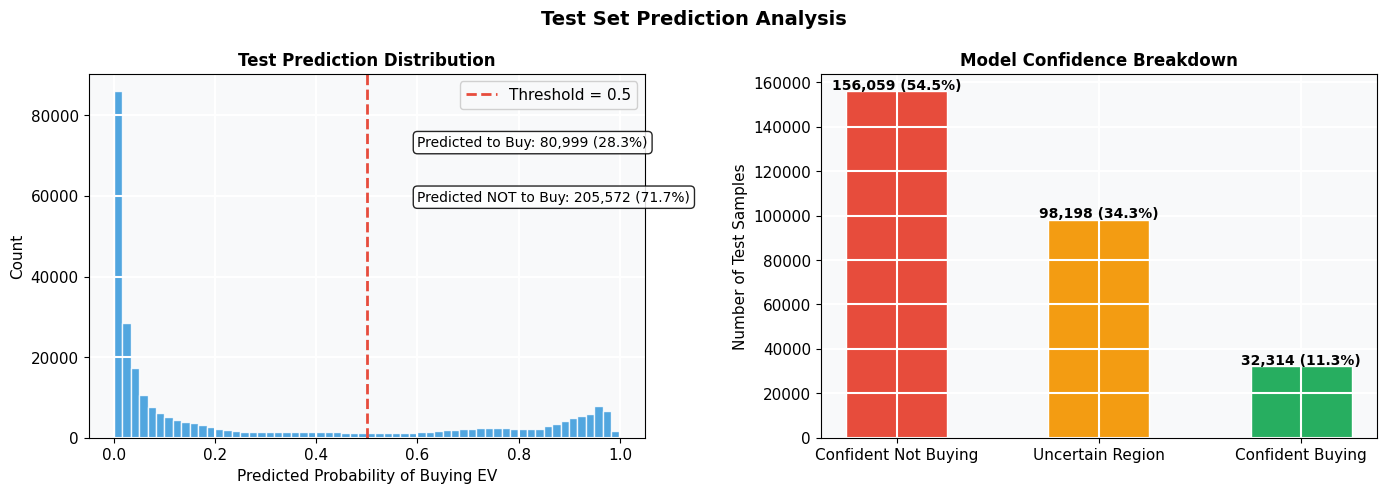

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Test Set Prediction Analysis', fontsize=14, fontweight='bold')

# Left: histogram
axes[0].hist(test_preds, bins=60, color='#3498db', edgecolor='white', alpha=0.85)
axes[0].axvline(0.5, color=NO_BUY, linestyle='--', linewidth=2.0, label='Threshold = 0.5')
axes[0].set_title('Test Prediction Distribution', fontweight='bold', fontsize=12)
axes[0].set_xlabel('Predicted Probability of Buying EV')
axes[0].set_ylabel('Count')
axes[0].legend(framealpha=0.9)

n_buy   = int((test_preds >= 0.5).sum())
n_nobuy = int((test_preds <  0.5).sum())
pct_buy = n_buy / len(test_preds) * 100
ymax = axes[0].get_ylim()[1]
axes[0].text(0.60, ymax * 0.80, f'Predicted to Buy: {n_buy:,} ({pct_buy:.1f}%)',
             fontsize=10, bbox=dict(boxstyle='round', facecolor='white', alpha=0.85))
axes[0].text(0.60, ymax * 0.65, f'Predicted NOT to Buy: {n_nobuy:,} ({100 - pct_buy:.1f}%)',
             fontsize=10, bbox=dict(boxstyle='round', facecolor='white', alpha=0.85))

# Right: confidence breakdown
n_conf_no  = int((test_preds < 0.10).sum())
n_uncert   = int(((test_preds >= 0.10) & (test_preds <= 0.90)).sum())
n_conf_yes = int((test_preds > 0.90).sum())
total      = len(test_preds)

cats   = ['Confident Not Buying', 'Uncertain Region', 'Confident Buying']
counts = [n_conf_no, n_uncert, n_conf_yes]
clrs   = [NO_BUY, '#f39c12', BUY]

bars = axes[1].bar(cats, counts, color=clrs, width=0.5, edgecolor='white')
axes[1].set_title('Model Confidence Breakdown', fontweight='bold', fontsize=12)
axes[1].set_ylabel('Number of Test Samples')

for bar, cnt in zip(bars, counts):
    pct = cnt / total * 100
    axes[1].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + total * 0.003,
                 f'{cnt:,} ({pct:.1f}%)',
                 ha='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig('test_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

**Reading the charts:**

- **Distribution (left):** Most predictions are pushed toward the extremes (near 0 and near 1),
  which is the sign of a confident model. A flat uniform distribution across 0-1 would indicate
  the model is not learning. The spike near 0 is expected given the heavy class imbalance (~82.5%
  negative class).
- **Confidence breakdown (right):** The vast majority of test samples fall in the "Confident Not
  Buying" bucket. The "Uncertain Region" (0.10 to 0.90) contains the genuinely hard cases where
  the model's prediction matters most for the AUC score - these are the samples where better
  feature engineering would have the biggest impact.

## 15. Results Summary

| Fold | OOF AUC |
|------|---------|
| 1 | 0.94469 |
| 2 | 0.94493 |
| 3 | 0.94540 |
| 4 | 0.94575 |
| 5 | 0.94656 |
| 6 | 0.94684 |
| 7 | 0.94559 |
| 8 | 0.94666 |
| 9 | 0.94671 |
| 10 | 0.94497 |
| **Overall** | **0.94580** |

**Public LB: 0.94590**

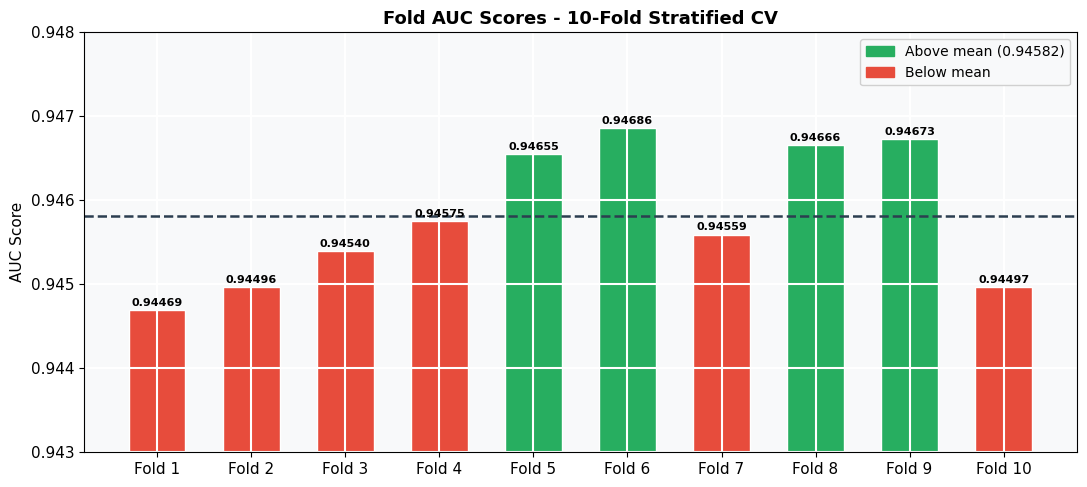

In [16]:
# Fold AUC bar chart - bars colored above/below mean
mean_auc   = np.mean(fold_aucs)
fold_labels = [f'Fold {i}' for i in range(1, 11)]
bar_colors  = [BUY if v >= mean_auc else NO_BUY for v in fold_aucs]

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(fold_labels, fold_aucs, color=bar_colors, width=0.6, edgecolor='white')

ax.axhline(mean_auc, color='#2c3e50', linestyle='--', linewidth=1.8,
           label=f'Mean OOF AUC = {mean_auc:.5f}')
ax.set_ylim(0.9430, 0.9480)
ax.set_title('Fold AUC Scores - 10-Fold Stratified CV', fontweight='bold', fontsize=13)
ax.set_ylabel('AUC Score')
ax.legend(framealpha=0.9, fontsize=11)

for bar, val in zip(bars, fold_aucs):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.00005,
            f'{val:.5f}', ha='center', fontsize=8, fontweight='bold')

legend_handles = [
    mpatches.Patch(color=BUY,    label=f'Above mean ({mean_auc:.5f})'),
    mpatches.Patch(color=NO_BUY, label='Below mean'),
]
ax.legend(handles=legend_handles, framealpha=0.9, fontsize=10)

plt.tight_layout()
plt.savefig('fold_aucs.png', dpi=150, bbox_inches='tight')
plt.show()

**Reading the chart:**

- The variance across folds is very low (range: 0.94469 to 0.94684 = 0.00215). Low variance
  indicates the model generalizes consistently - this is a good sign that the CV score is a
  reliable proxy for the LB score.
- Folds 5, 6, 8, and 9 perform above the mean. This is normal fold-to-fold variation caused
  by slightly different class distributions in each split.
- The OOF AUC (0.94580) and Public LB (0.94590) are within 0.00010 of each other, confirming
  the CV setup is not overfitting and the public score is trustworthy.

## 16. What Didn't Work

An honest record of the dead ends.

| What I Tried | Why I Expected It to Help | Why It Didn't |
|---|---|---|
| **CatBoost** | Native categorical handling, usually competitive with LGB | Slightly lower OOF on this dataset; LGB + explicit encoding wins |
| **7-model stacking** | Diversity of base learners typically improves blends | Score progression shows the stack was beaten by a single well-engineered LGB. FE was doing the heavy lifting, not model diversity |
| **SMOTE / oversampling** | Standard fix for class imbalance | `is_unbalance=True` outperforms synthetic oversampling; LGB handles imbalance better natively |
| **Polynomial features** | Capture non-linear interactions between raw features | Generated hundreds of features, nearly all dropped by the constant/correlation filter |
| **5-level Triple TE** | More smoothing levels = more diverse views | No meaningful OOF improvement over 3 levels, significant runtime cost |
| **Pseudo-labelling** | High-confidence test predictions can supplement training | OOF improved but LB degraded - classic CV-LB gap warning |
| **CatBoost + LGB blend** | Model diversity in the blend | Consistently underperformed the solo LGB once FE was fully applied |

The core lesson: in synthetic Kaggle datasets, feature engineering targeting generator artifacts
almost always matters more than model diversity or ensemble complexity.

## 17. Key Lessons

1. **Digit decomposition** is particularly useful for synthetic data. The ablation study
   shows it gave the biggest single gain in this notebook (+0.00143).

2. **Frequency encoding** captures distributional anomalies without using any target
   information, making it completely safe to compute on train + test combined.

3. **Triple Target Encoding** gives the model multiple smoothed views of group-level target
   rates. It must be applied strictly inside CV folds to prevent leakage.

4. **A single strong LightGBM model** can outperform a more complicated stacking framework
   when feature engineering is doing most of the work.

5. **OOF and test prediction analysis** are a reliable way to verify model behavior before
   submitting. Low fold variance and a tight OOF-to-LB gap both confirm the model is healthy.

6. **EDA pays off early.** The Subsidy / Home Charging / Range Anxiety dominance was visible
   in a few bar charts - and directly motivated the interaction terms that moved the score most.

---

If this notebook helped you, please consider upvoting - it really helps!